## 1 setup

In [1]:
%pip install -q pandas numpy matplotlib seaborn 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

np.random.seed(42)
sns.set_style("whitegrid")
pd.set_option("display.max_columns",20)
pd.set_option("display.float_format","{:.3f}".format)

## Load the dataset

In [8]:
df=pd.read_csv("insurance.csv")

In [9]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


In [10]:
df.shape

(1338, 7)

In [15]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

## Data Quality checks

In [16]:
nums_cols=["age","bmi","children","charges"]
cat_cols=["sex","smoker","region"]

print(nums_cols)
print(cat_cols)

['age', 'bmi', 'children', 'charges']
['sex', 'smoker', 'region']


In [17]:
df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [19]:
df.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [23]:
  df[nums_cols].describe()

,age,bmi,children,charges
count,1338.000,1338.000,1338.000,1338.000
mean,39.207,30.663,1.095,13270.422
std,14.050,6.098,1.205,12110.011
min,18.000,15.960,0.000,1121.874
25%,27.000,26.296,0.000,4740.287
50%,39.000,30.400,1.000,9382.033
75%,51.000,34.694,2.000,16639.913
max,64.000,53.130,5.000,63770.428


In [24]:
df.describe()

,age,bmi,children,charges
count,1338.000,1338.000,1338.000,1338.000
mean,39.207,30.663,1.095,13270.422
std,14.050,6.098,1.205,12110.011
min,18.000,15.960,0.000,1121.874
25%,27.000,26.296,0.000,4740.287
50%,39.000,30.400,1.000,9382.033
75%,51.000,34.694,2.000,16639.913
max,64.000,53.130,5.000,63770.428


In [25]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [34]:
missing_count=df.isna().sum().sort_values(ascending=False)
missing_percent=(df.isna().mean()*100).sort_values(ascending=False)
missing_summary=pd.DataFrame({
    "missing_count":missing_count,
    "missing_percent":missing_percent
})
print("Missing Values summary")
missing_summary

Missing Values summary


,missing_count,missing_percent
age,0,0.000
sex,0,0.000
bmi,0,0.000
children,0,0.000
smoker,0,0.000
region,0,0.000
charges,0,0.000


In [37]:
for col in df.columns:
    print(df[col].value_counts())
    print("-"*50)

age
18    69
19    68
46    29
52    29
48    29
20    29
45    29
47    29
51    29
50    29
28    28
25    28
23    28
27    28
22    28
26    28
24    28
21    28
53    28
54    28
49    28
31    27
30    27
41    27
40    27
43    27
44    27
29    27
42    27
33    26
32    26
56    26
34    26
55    26
57    26
37    25
59    25
35    25
38    25
36    25
58    25
39    25
60    23
62    23
63    23
61    23
64    22
Name: count, dtype: int64
--------------------------------------------------
sex
male      676
female    662
Name: count, dtype: int64
--------------------------------------------------
bmi
32.300    13
28.310     9
28.880     8
34.100     8
30.800     8
          ..
53.130     1
39.710     1
32.870     1
44.700     1
30.970     1
Name: count, Length: 548, dtype: int64
--------------------------------------------------
children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64
--------------------------------------------------
smoker
no 

In [44]:
duplicated_mask=df.duplicated()
num_duplicate=duplicated_mask.sum()
df_no_duplicates=df.drop_duplicates()
print(df_no_duplicates.shape)

(1337, 7)


In [42]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [52]:
expected_types={
    "age":"int64",
    "sex":"str",
    "bmi":"int64",
    "children":"int64",
    "smoker":"object",
    "region":"object",
    "charges":"int64"
}

print("data types validation:")
for col,expected in expected_types.items():
    if col in df.columns:
        actual=df[col].dtypes
        print(f"{col}: actual={actual}          ,expected: {expected}")

data types validation:
age: actual=int64          ,expected: int64
sex: actual=str          ,expected: str
bmi: actual=float64          ,expected: int64
children: actual=int64          ,expected: int64
smoker: actual=str          ,expected: object
region: actual=str          ,expected: object
charges: actual=float64          ,expected: int64


3. Constant and quasi columns

In [67]:
n_row=len(df)
nunique=df.nunique()

constant_cols=nunique[nunique==1].index.to_list()

quasi_constant_cols=[]

for col in df.columns:
    top_freq=df[col].value_counts(normalize=True,dropna=False).values[0]
    if top_freq >0.9 and col not in constant_cols:
        quasi_constant_cols.append(col)
        
        
print(quasi_constant_cols)
    

[]


In [70]:
id_likes_cols=[]
for col in df.columns:
    if df[col].nunique(dropna=False)==len(df):
        id_like_cols.append(col)

print("Id like columns:",id_likes_cols)

Id like columns: []


In [75]:
zero_share={}
for col in nums_cols:
    zero_share[col]=(df[col]==0).mean()
    
zero_share_series=pd.Series(zero_share).sort_values(ascending=False)
zero_share_series

high_zero_threshold=0.8
high_zero_cols=zero_share_series[zero_share_series>=high_zero_threshold]
high_zero_cols

Series([], dtype: float64)

In [ ]:
# 

## Univariate Analysis

In [76]:
df[nums_cols].describe()

,age,bmi,children,charges
count,1338.000,1338.000,1338.000,1338.000
mean,39.207,30.663,1.095,13270.422
std,14.050,6.098,1.205,12110.011
min,18.000,15.960,0.000,1121.874
25%,27.000,26.296,0.000,4740.287
50%,39.000,30.400,1.000,9382.033
75%,51.000,34.694,2.000,16639.913
max,64.000,53.130,5.000,63770.428


In [83]:
df[nums_cols].mean()
df[nums_cols].median()
df[nums_cols].mode()



,age,bmi,children,charges
0,18,32.300,0,1639.563


In [84]:
df[nums_cols].std()

age           14.050
bmi            6.098
children       1.205
charges    12110.011
dtype: float64

In [85]:
df[nums_cols].var()

age              197.401
bmi               37.188
children           1.453
charges    146652372.153
dtype: float64

In [86]:
df[nums_cols].skew()

age        0.056
bmi        0.284
children   0.938
charges    1.516
dtype: float64

In [87]:
df[nums_cols].kurtosis()

age        -1.245
bmi        -0.051
children    0.202
charges     1.606
dtype: float64

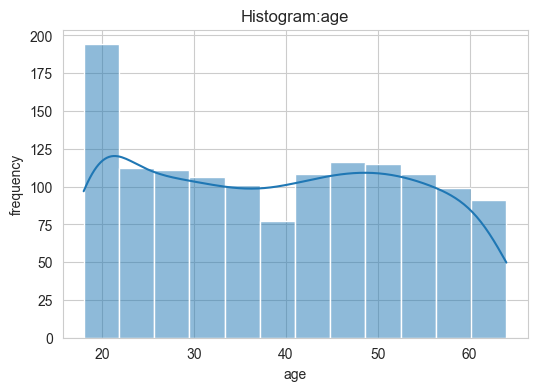

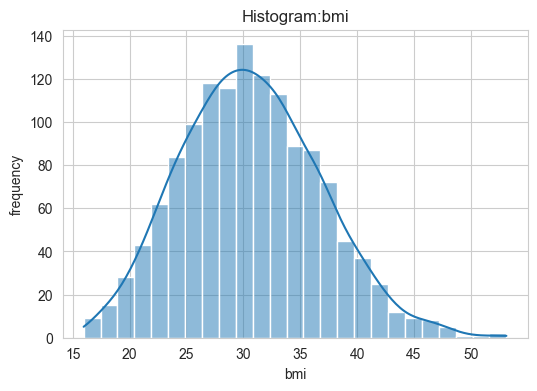

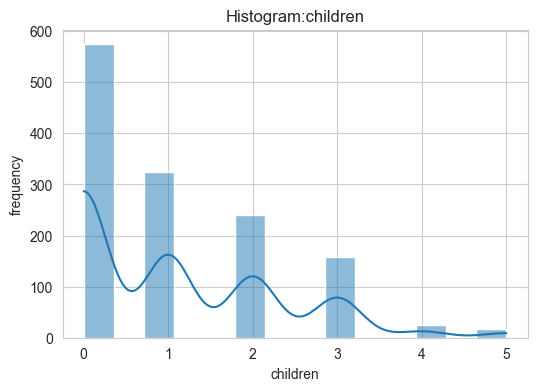

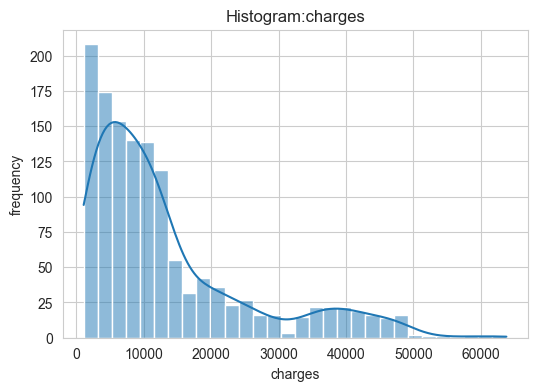

In [88]:
for col in nums_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True)
    plt.title(f"Histogram:{col}")
    plt.xlabel(col)
    plt.ylabel("frequency")
    plt.show() 

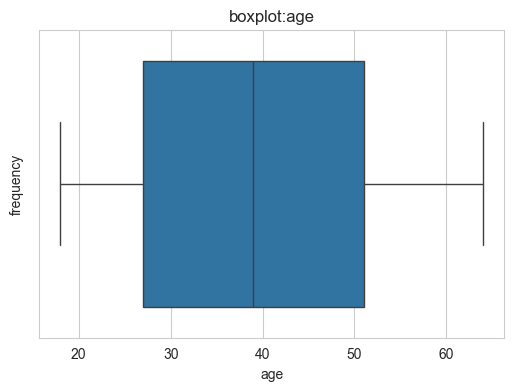

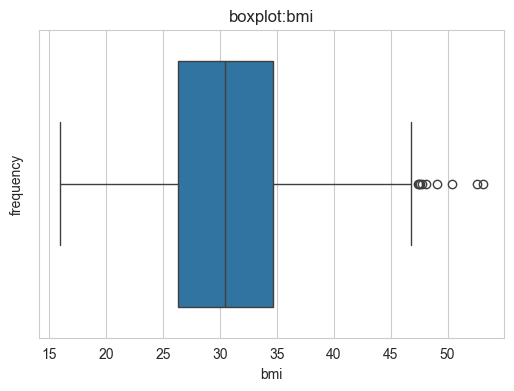

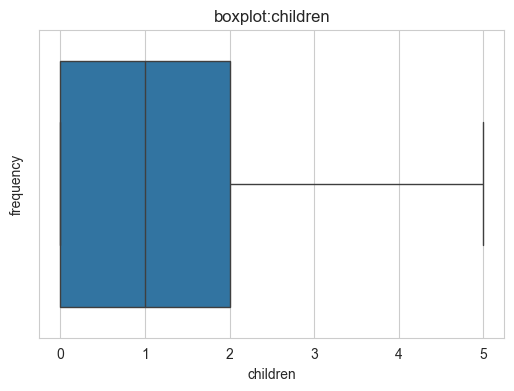

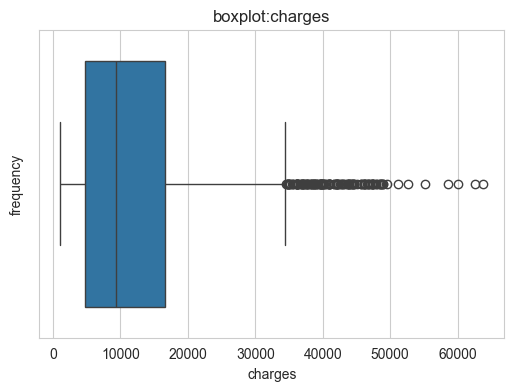

In [91]:
for col in nums_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col]
                )
    plt.title(f"boxplot:{col}")
    plt.xlabel(col)
    plt.ylabel("frequency")
    plt.show() 

In [92]:
cat_cols

['sex', 'smoker', 'region']

In [96]:
df[cat_cols].head()

,sex,smoker,region
0,female,yes,southwest
1,male,no,southeast
2,male,no,southeast
3,male,no,northwest
4,male,no,northwest


In [103]:
for col in cat_cols:
    print(df[col].value_counts())
    # print(mean)

sex
male      676
female    662
Name: count, dtype: int64
smoker
no     1064
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


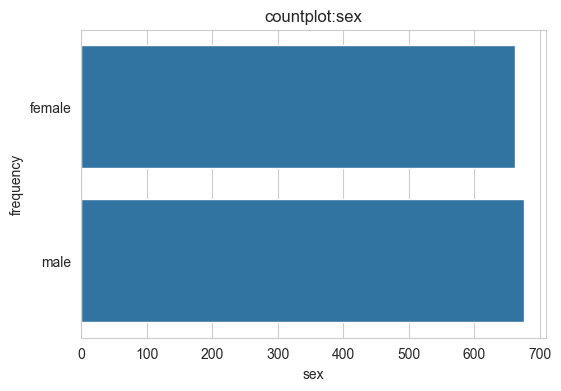

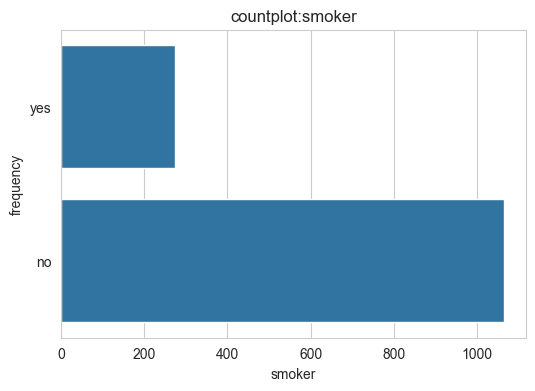

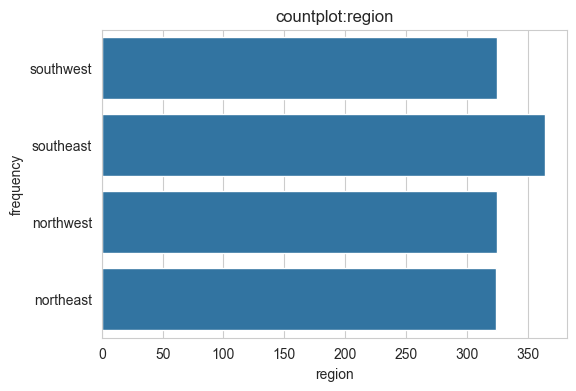

In [99]:
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(df[col])
    plt.title(f"countplot:{col}")
    plt.xlabel(col)
    plt.ylabel("frequency")
    plt.show() 

## Bivariate Analysis

In [104]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


In [117]:
nums_cols

['age', 'bmi', 'children', 'charges']

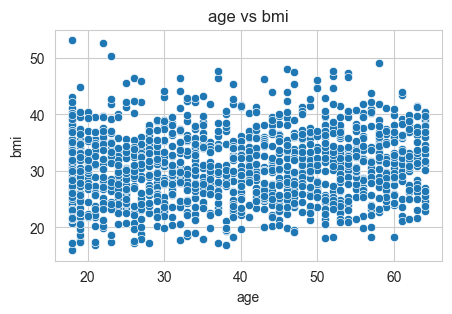

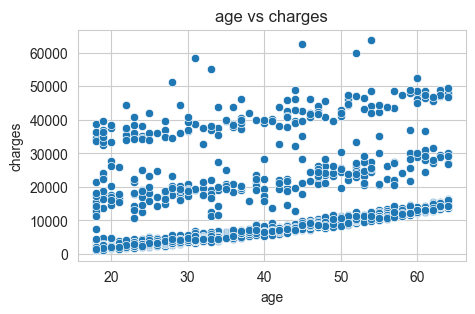

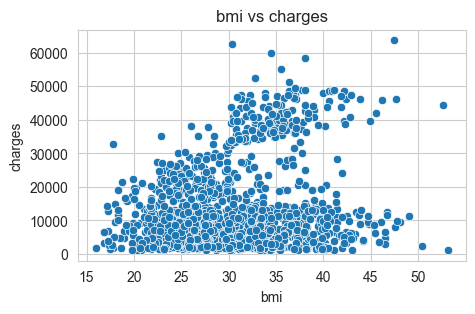

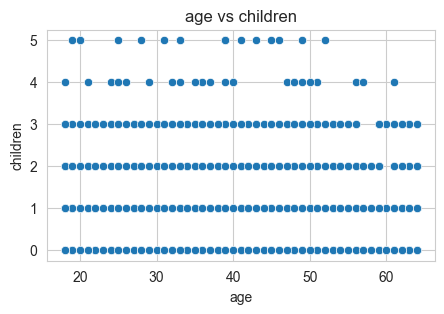

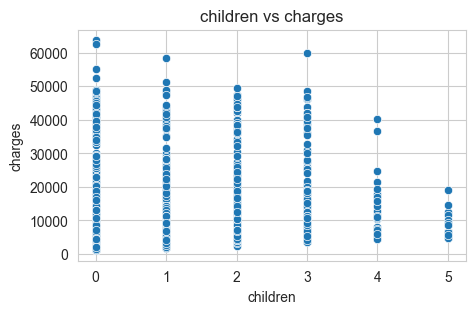

In [122]:
num_pairs=[
    ("age","bmi"),
    ("age","charges"),
    ("bmi","charges"),
    ("age","children"),
    ("children","charges")
]
for x,y in num_pairs:
    plt.figure(figsize=(5,3))
    sns.scatterplot(x=df[x],y=df[y])
    plt.title(f"{x } vs {y}")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show()

In [123]:
df[nums_cols].corr()

,age,bmi,children,charges
age,1.000,0.109,0.042,0.299
bmi,0.109,1.000,0.013,0.198
children,0.042,0.013,1.000,0.068
charges,0.299,0.198,0.068,1.000


In [125]:
print("Pearsonr correlation with fare:")
for col in nums_cols:
    if col!="age":
        r,p=pearsonr(df[col],df["age"])
        print(f"{col} vs age: r={r:.3f} ,p ={p:.3f}")

Pearsonr correlation with fare:
bmi vs age: r=0.109 ,p =0.000
children vs age: r=0.042 ,p =0.120
charges vs age: r=0.299 ,p =0.000


Numerical vs Categorical

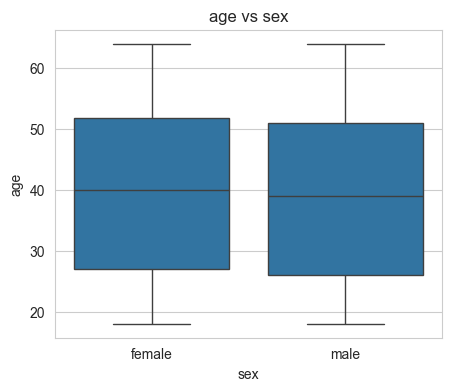

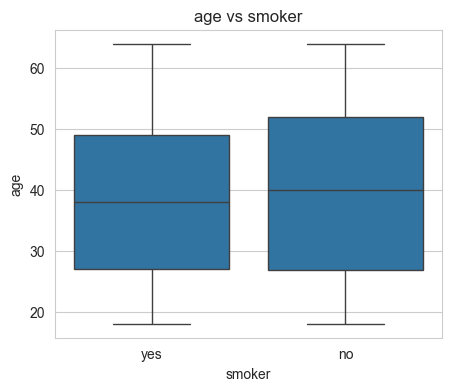

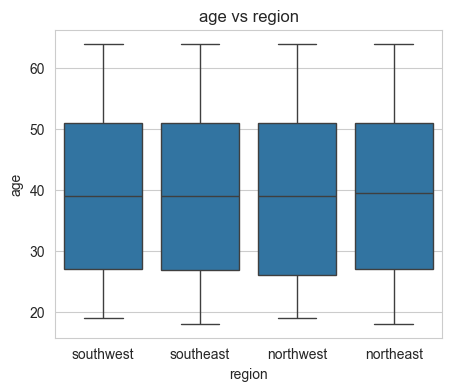

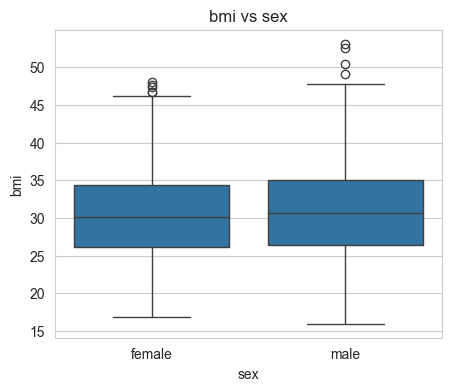

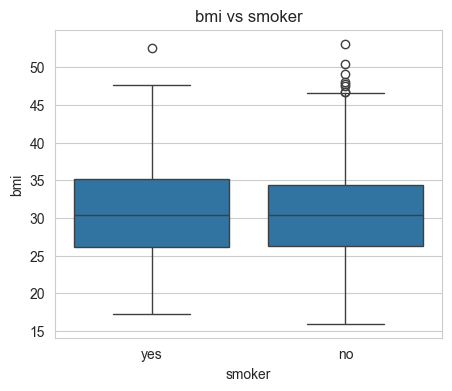

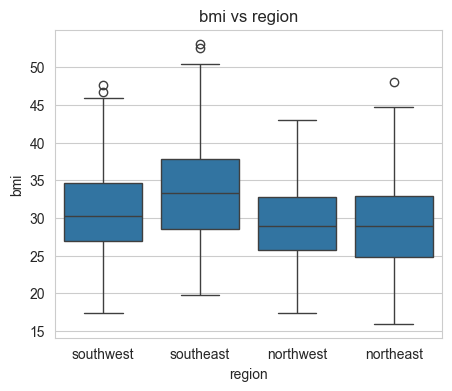

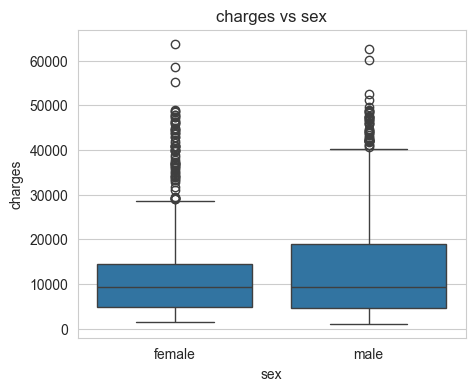

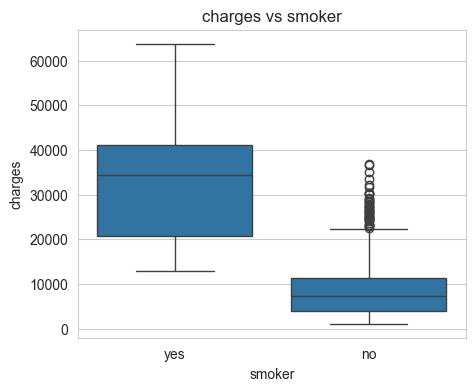

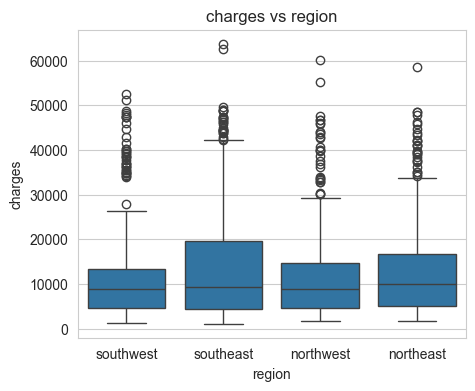

In [133]:
nums_for_box=["age","bmi","charges"]
cat_for_box=["sex","smoker","region"]

for num in nums_for_box:
    for cat in cat_for_box:
        plt.figure(figsize=(5,4))
        sns.boxplot(x=df[cat],y=df[num])
        plt.title(f"{num} vs {cat}")
        plt.xlabel(cat)
        plt.ylabel(num)
        plt.show()

groupby statitics

In [134]:
df[nums_cols+["sex"]].groupby("sex").mean()

,age,bmi,children,charges
sex,,,,
female,39.503,30.378,1.074,12569.579
male,38.917,30.943,1.115,13956.751


In [135]:
cat_cols

['sex', 'smoker', 'region']

In [136]:
df[nums_cols].groupby("age").mean()

,bmi,children,charges
age,,,
18,31.326,0.449,7086.218
19,28.597,0.426,9747.909
20,30.633,0.862,10159.698
21,28.186,0.786,4730.464
22,31.088,0.714,10012.933
23,31.454,1.000,12419.820
24,29.143,0.464,10648.016
25,29.694,1.286,9838.365
26,29.429,1.071,6133.825


In [138]:
for category in ["sex","smoker","region"]:
    print(df[nums_cols+[category]].groupby(category).mean())
    print("_"*40)

          age    bmi  children   charges
sex                                     
female 39.503 30.378     1.074 12569.579
male   38.917 30.943     1.115 13956.751
________________________________________
          age    bmi  children   charges
smoker                                  
no     39.385 30.652     1.090  8434.268
yes    38.515 30.708     1.113 32050.232
________________________________________
             age    bmi  children   charges
region                                     
northeast 39.269 29.174     1.046 13406.385
northwest 39.197 29.200     1.148 12417.575
southeast 38.940 33.356     1.049 14735.411
southwest 39.455 30.597     1.142 12346.937
________________________________________


Categorical vs Categorical

In [143]:
print("crosstab : sex vs Smoker")
print(pd.crosstab(df["sex"],df["smoker"]))
print("-"*(40))

print("crosstab : smoker vs region")
print(pd.crosstab(df["region"],df["smoker"]))
print("-"*(40))


crosstab : sex vs Smoker
smoker   no  yes
sex             
female  547  115
male    517  159
----------------------------------------
crosstab : smoker vs region
smoker      no  yes
region             
northeast  257   67
northwest  267   58
southeast  273   91
southwest  267   58
----------------------------------------


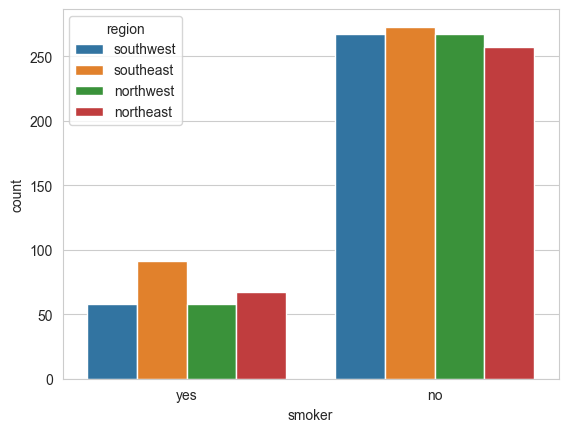

In [147]:
sns.countplot(x=df["smoker"],hue=df["region"])
plt.show()

## Multivariate Analysis


In [151]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


In [ ]:
df.shape 

(1338, 7)

In [154]:
nums_cols

['age', 'bmi', 'children', 'charges']

In [155]:
cat_cols

['sex', 'smoker', 'region']